In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [4]:
df = pd.read_csv("../data/creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [5]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
predictions = model.predict(X_valid)

In [7]:
probabilities = model.predict_proba(
    X_valid
)[:,1]

In [8]:
accuracy = accuracy_score(
    y_valid,
    predictions
)

precision = precision_score(
    y_valid,
    predictions
)

recall = recall_score(
    y_valid,
    predictions
)

f1 = f1_score(
    y_valid,
    predictions
)

auc = roc_auc_score(
    y_valid,
    probabilities
)

In [9]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.998735999438222
Precision: 0.5984848484848485
Recall   : 0.8061224489795918
F1 Score : 0.6869565217391305
ROC-AUC  : 0.9134207970610867


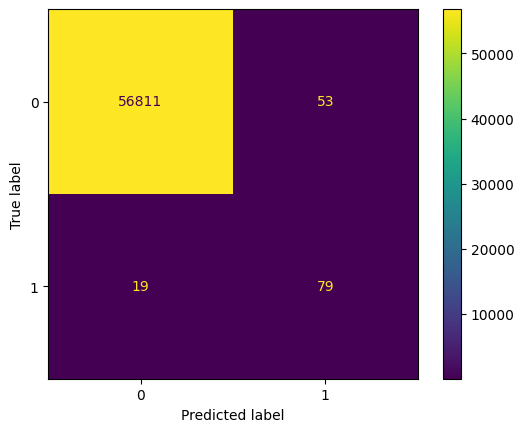

In [10]:
cm = confusion_matrix(
    y_valid,
    predictions
)

display = ConfusionMatrixDisplay(cm)

display.plot()

plt.show()

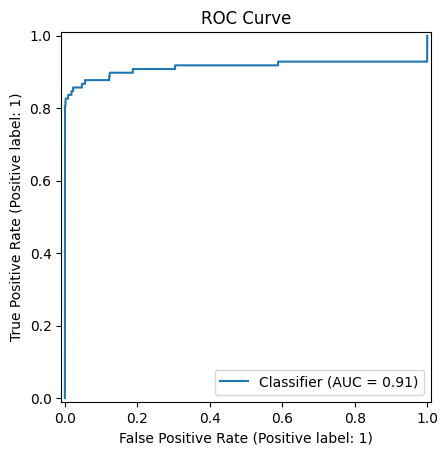

In [11]:
RocCurveDisplay.from_predictions(
    y_valid,
    probabilities
)

plt.title("ROC Curve")

plt.show()

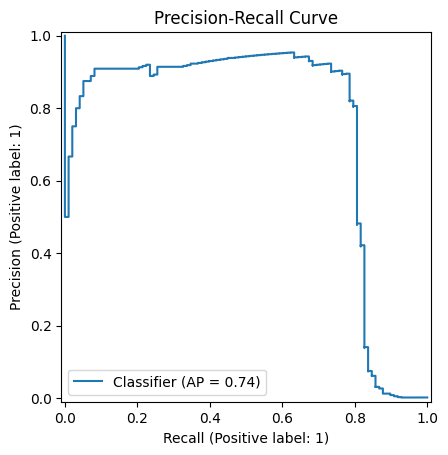

In [12]:
PrecisionRecallDisplay.from_predictions(
    y_valid,
    probabilities
)

plt.title("Precision-Recall Curve")

plt.show()

In [13]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results

,Metric,Score
0,Accuracy,0.998736
1,Precision,0.598485
2,Recall,0.806122
3,F1 Score,0.686957
4,ROC-AUC,0.913421
